<a href="https://colab.research.google.com/github/DhimanTarafdar/ecg-classification/blob/main/ecg_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# STAGE 0: ENVIRONMENT SETUP, REPRODUCIBILITY & PROJECT STRUCTURE
# Project: Quality-Aware Cascaded ECG Digitization → Diagnostic Classification
# ==============================================================================

# 1. Install required libraries
!pip install -q wfdb neurokit2 torchmetrics scikit-learn seaborn tqdm

import os
import random
import numpy as np
import torch
import json
from datetime import datetime
from google.colab import drive

class ClassificationPipelineEnvironment:
    def __init__(self, base_dir='/content/drive/MyDrive/ECG_Classification_QCE'):
        self.base_dir = base_dir

        # Previous Digitization Pipeline paths (read-only)
        self.digitization_dir = '/content/drive/MyDrive/ECG_Digitization_Q1'

        self.dirs = {
            # New Classification project directories
            'processed_data'   : os.path.join(base_dir, 'data/processed'),
            'features'         : os.path.join(base_dir, 'data/features'),
            'models'           : os.path.join(base_dir, 'checkpoints/models'),
            'states'           : os.path.join(base_dir, 'checkpoints/states'),
            'logs'             : os.path.join(base_dir, 'logs'),
            'outputs'          : os.path.join(base_dir, 'outputs/predictions'),
            'visualizations'   : os.path.join(base_dir, 'outputs/visualizations'),
            'tables'           : os.path.join(base_dir, 'outputs/tables'),

            # Links to previous pipeline
            'digitization_model' : os.path.join(self.digitization_dir, 'checkpoints/best_multitask_unet.pth'),
            'digitization_data'  : os.path.join(self.digitization_dir, 'data'),
            'digitization_outputs': os.path.join(self.digitization_dir, 'outputs'),
        }

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def mount_drive(self):
        if not os.path.exists('/content/drive'):
            print("[INFO] Mounting Google Drive...")
            drive.mount('/content/drive')
        else:
            print("[INFO] Google Drive already mounted.")

    def create_directories(self):
        for name, path in self.dirs.items():
            if name.startswith('digitization'):
                continue  # skip read-only paths
            os.makedirs(path, exist_ok=True)
        print(f"[SUCCESS] Classification directory structure created at:\n  {self.base_dir}")

    def set_reproducibility(self, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        print(f"[SUCCESS] Random seed set to {seed} (fully deterministic).")

    def init_logger(self):
        log_file = os.path.join(self.dirs['logs'], 'classification_pipeline_log.json')
        if not os.path.exists(log_file):
            init_data = {
                "project": "Quality-Aware Cascaded ECG Classification (after Digitization)",
                "start_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "device": str(self.device),
                "digitization_model_path": self.dirs['digitization_model'],
                "stages_completed": [],
                "notes": "Journal-ready pipeline with Confidence-Guided + Selective Classification"
            }
            with open(log_file, 'w') as f:
                json.dump(init_data, f, indent=4)
            print("[INFO] Classification Pipeline Logger initialized.")
        else:
            print("[INFO] Existing logger found. Resuming session...")

    def verify_digitization_assets(self):
        """Check that the previous pipeline assets are accessible."""
        print("\n[INFO] Verifying Digitization Pipeline assets...")

        model_path = self.dirs['digitization_model']
        if os.path.exists(model_path):
            size_mb = os.path.getsize(model_path) / (1024 * 1024)
            print(f"  [OK] Digitization model found: {model_path}")
            print(f"       Size: {size_mb:.1f} MB")
        else:
            print(f"  [ERROR] Digitization model NOT found at: {model_path}")
            print("         Please check the path.")

        # Check other important folders
        for key in ['digitization_data', 'digitization_outputs']:
            path = self.dirs[key]
            status = "OK" if os.path.exists(path) else "MISSING"
            print(f"  [{status}] {key}: {path}")

    def setup(self):
        print("=" * 70)
        print("  QUALITY-AWARE CASCADED ECG CLASSIFICATION PIPELINE")
        print("  Target: Q1/Q2 Journal | Novelty: Confidence-Guided + Selective Classification")
        print("=" * 70)
        print(f"Device Detected: {self.device}")

        self.mount_drive()
        self.create_directories()
        self.set_reproducibility(seed=42)
        self.init_logger()
        self.verify_digitization_assets()

        print("\n=== Stage 0 Complete: Environment Ready ===")
        return self

# -------------------------------------------------
# Execute Setup
# -------------------------------------------------
env = ClassificationPipelineEnvironment()
env = env.setup()

print("\n[READY] You can now proceed to the next cell.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
  QUALITY-AWARE CASCADED ECG CLASSIFICATION PIPELINE
  Target: Q1/Q2 Journal | Novelty: Confidence-Guided + Selective Classification
Device Detected: cuda
[INFO] Mounting Google Drive...
Mounted at /content/drive
[SUCCESS] Classification directory stru

In [ ]:
# ==============================================================================
# STAGE 1: PTB-XL METADATA, SUPERCLASS LABELS & OFFICIAL BENCHMARK SPLITS
# ==============================================================================

import os
import ast
import json
import pandas as pd
import numpy as np
from datetime import datetime

# -------------------------------------------------
# Paths
# -------------------------------------------------
RAW_DIR = "/content/data/raw/ptb-xl-1.0.3"
PROCESSED_DIR = env.dirs['processed_data']
DIGITIZATION_PROCESSED = os.path.join(env.digitization_dir, 'data/processed')

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# -------------------------------------------------
# 1. Ensure PTB-XL raw data is available
# -------------------------------------------------
def ensure_ptbxl_raw():
    csv_path = os.path.join(RAW_DIR, "ptbxl_database.csv")

    if os.path.exists(csv_path):
        print("[CHECKPOINT] PTB-XL raw data already present on local SSD.")
        return True

    print("[INFO] PTB-XL not found on local SSD. Syncing from AWS S3 (fast)...")
    !pip install -q awscli
    !aws s3 sync --no-sign-request s3://physionet-open/ptb-xl/1.0.3/ {RAW_DIR}

    if os.path.exists(csv_path):
        print("[SUCCESS] PTB-XL synced successfully.")
        return True
    else:
        print("[ERROR] Failed to sync PTB-XL.")
        return False

# -------------------------------------------------
# 2. Load metadata + map Superclass
# -------------------------------------------------
def load_ptbxl_metadata(raw_dir):
    print("[INFO] Loading PTB-XL metadata and mapping diagnostic superclasses...")

    df = pd.read_csv(os.path.join(raw_dir, "ptbxl_database.csv"), index_col="ecg_id")
    df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

    scp_df = pd.read_csv(os.path.join(raw_dir, "scp_statements.csv"), index_col=0)
    scp_diag = scp_df[scp_df.diagnostic == 1]

    def map_superclass(scp_dict):
        classes = []
        for key in scp_dict.keys():
            if key in scp_diag.index:
                classes.append(scp_diag.loc[key].diagnostic_class)
        return list(set(classes))

    df["diagnostic_superclass"] = df.scp_codes.apply(map_superclass)

    # Keep only records that have at least one diagnostic superclass
    df = df[df["diagnostic_superclass"].map(len) > 0].copy()

    print(f"[SUCCESS] Metadata loaded. Usable records: {len(df)}")
    return df

# -------------------------------------------------
# 3. Official PTB-XL stratified splits (Fold based)
# -------------------------------------------------
def create_official_splits(df, save_dir):
    """
    Official recommended split:
    - Fold 1-8 : Train
    - Fold 9   : Validation
    - Fold 10  : Test
    """
    print("[INFO] Creating official PTB-XL stratified splits...")

    train_df = df[df.strat_fold <= 8]
    val_df   = df[df.strat_fold == 9]
    test_df  = df[df.strat_fold == 10]

    splits = {
        "train_ids": train_df.index.tolist(),
        "val_ids"  : val_df.index.tolist(),
        "test_ids" : test_df.index.tolist(),
        "counts": {
            "train": len(train_df),
            "val"  : len(val_df),
            "test" : len(test_df),
            "total": len(df)
        }
    }

    # Save split manifest
    split_path = os.path.join(save_dir, "official_splits.json")
    with open(split_path, "w") as f:
        json.dump(splits, f, indent=4)

    print("\n=== OFFICIAL SPLIT SUMMARY ===")
    print(f"  Train : {splits['counts']['train']:5d} records")
    print(f"  Val   : {splits['counts']['val']:5d} records")
    print(f"  Test  : {splits['counts']['test']:5d} records")
    print(f"  Total : {splits['counts']['total']:5d} records")
    print(f"[SUCCESS] Split manifest saved → {split_path}")

    return splits, train_df, val_df, test_df

# -------------------------------------------------
# 4. Superclass distribution + Multi-hot encoding helper
# -------------------------------------------------
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]

def add_multihot_labels(df):
    """Add multi-hot columns for the 5 superclasses."""
    for sc in SUPERCLASSES:
        df[f"label_{sc}"] = df["diagnostic_superclass"].apply(lambda x: 1 if sc in x else 0)
    return df

def print_class_distribution(df, split_name="Full"):
    print(f"\n--- Class Distribution ({split_name}) ---")
    for sc in SUPERCLASSES:
        count = df[f"label_{sc}"].sum()
        pct = 100 * count / len(df)
        print(f"  {sc:5s} : {count:5d} ({pct:5.1f}%)")

# -------------------------------------------------
# Execute
# -------------------------------------------------
if ensure_ptbxl_raw():
    df_meta = load_ptbxl_metadata(RAW_DIR)
    df_meta = add_multihot_labels(df_meta)

    splits, train_df, val_df, test_df = create_official_splits(df_meta, PROCESSED_DIR)

    # Save full processed metadata
    meta_path = os.path.join(PROCESSED_DIR, "ptbxl_classification_metadata.csv")
    df_meta.to_csv(meta_path)
    print(f"\n[SUCCESS] Full metadata saved → {meta_path}")

    # Show distributions
    print_class_distribution(df_meta, "Full Dataset")
    print_class_distribution(train_df, "Train")
    print_class_distribution(val_df, "Validation")
    print_class_distribution(test_df, "Test")

    # Update logger
    log_file = os.path.join(env.dirs['logs'], 'classification_pipeline_log.json')
    with open(log_file, 'r') as f:
        log_data = json.load(f)

    if "Stage 1: Metadata & Official Splits" not in log_data["stages_completed"]:
        log_data["stages_completed"].append("Stage 1: Metadata & Official Splits")
        log_data["last_updated"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        log_data["num_records"] = len(df_meta)
        log_data["splits"] = splits["counts"]

        with open(log_file, 'w') as f:
            json.dump(log_data, f, indent=4)

    print("\n=== Stage 1 Complete: Labels & Splits Ready ===")
else:
    print("[FATAL] Cannot proceed without PTB-XL data.")

Streaming output truncated to the last 5000 lines.
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19359_hr.dat to data/raw/ptb-xl-1.0.3/records500/19000/19359_hr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19361_hr.hea to data/raw/ptb-xl-1.0.3/records500/19000/19361_hr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19360_hr.dat to data/raw/ptb-xl-1.0.3/records500/19000/19360_hr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19361_hr.dat to data/raw/ptb-xl-1.0.3/records500/19000/19361_hr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19363_hr.hea to data/raw/ptb-xl-1.0.3/records500/19000/19363_hr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19364_hr.hea to data/raw/ptb-xl-1.0.3/records500/19000/19364_hr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19362_hr.dat to data/raw/ptb-xl-1.0.3/records500/19000/19362_hr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records500

In [ ]:
# ==============================================================================
# STAGE 2: SIGNAL LOADING UTILITIES + FLEXIBLE DATASET CLASS
# Supports: (1) Original PTB-XL signals  (2) Digitized + Confidence signals
# ==============================================================================

import os
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import wfdb
from tqdm import tqdm

# -------------------------------------------------
# Constants
# -------------------------------------------------
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
NUM_CLASSES = len(SUPERCLASSES)
TARGET_LEN = 1000          # 10 seconds at 100 Hz
NUM_LEADS = 12

# -------------------------------------------------
# 1. Load official splits + metadata
# -------------------------------------------------
PROCESSED_DIR = env.dirs['processed_data']

with open(os.path.join(PROCESSED_DIR, "official_splits.json"), "r") as f:
    splits = json.load(f)

df_meta = pd.read_csv(os.path.join(PROCESSED_DIR, "ptbxl_classification_metadata.csv"), index_col="ecg_id")

print("[INFO] Loaded splits and metadata.")
print(f"  Train IDs : {len(splits['train_ids'])}")
print(f"  Val IDs   : {len(splits['val_ids'])}")
print(f"  Test IDs  : {len(splits['test_ids'])}")

# -------------------------------------------------
# 2. Helper: Load original PTB-XL signal (100 Hz)
# -------------------------------------------------
def load_original_signal(ecg_id, raw_dir="/content/data/raw/ptb-xl-1.0.3"):
    """
    Load 12-lead signal at 100 Hz and resample/pad to TARGET_LEN.
    Returns: signal (12, TARGET_LEN), success flag
    """
    # PTB-XL low-resolution path pattern
    folder = str(ecg_id).zfill(5)[:2] + "000"
    path = os.path.join(raw_dir, "records100", folder, f"{str(ecg_id).zfill(5)}_lr")

    try:
        signal, fields = wfdb.rdsamp(path)
        # signal shape: (time, leads) → we need (leads, time)
        signal = signal.T.astype(np.float32)

        # Simple resample / truncate / pad to TARGET_LEN
        C, T = signal.shape
        if T > TARGET_LEN:
            signal = signal[:, :TARGET_LEN]
        elif T < TARGET_LEN:
            pad = np.zeros((C, TARGET_LEN - T), dtype=np.float32)
            signal = np.concatenate([signal, pad], axis=1)

        return signal, True
    except Exception as e:
        return np.zeros((NUM_LEADS, TARGET_LEN), dtype=np.float32), False

# -------------------------------------------------
# 3. Helper: Multi-hot label vector
# -------------------------------------------------
def get_multihot_label(ecg_id, df):
    row = df.loc[ecg_id]
    label = np.array([row[f"label_{sc}"] for sc in SUPERCLASSES], dtype=np.float32)
    return label

# -------------------------------------------------
# 4. Main Dataset Class (flexible for both modes)
# -------------------------------------------------
class ECGClassificationDataset(Dataset):
    """
    mode = "original"   → clean PTB-XL signals (baseline / upper bound)
    mode = "digitized"  → will later load U-Net digitized signals + confidence
    """
    def __init__(self, ecg_ids, df_meta, mode="original",
                 digitized_dir=None, transform=None):
        self.ecg_ids = list(ecg_ids)
        self.df_meta = df_meta
        self.mode = mode
        self.digitized_dir = digitized_dir
        self.transform = transform

        print(f"[INFO] Dataset initialized | mode={mode} | samples={len(self.ecg_ids)}")

    def __len__(self):
        return len(self.ecg_ids)

    def __getitem__(self, idx):
        ecg_id = self.ecg_ids[idx]

        # ----- Label -----
        label = get_multihot_label(ecg_id, self.df_meta)

        # ----- Signal -----
        if self.mode == "original":
            signal, ok = load_original_signal(ecg_id)
            confidence = np.ones((NUM_LEADS, TARGET_LEN), dtype=np.float32)  # full confidence
            clean_ratio = 1.0
        else:
            # Placeholder for digitized mode (we will implement properly later)
            # For now return zeros so the class structure is ready
            signal = np.zeros((NUM_LEADS, TARGET_LEN), dtype=np.float32)
            confidence = np.zeros((NUM_LEADS, TARGET_LEN), dtype=np.float32)
            clean_ratio = 0.0

        # Optional transform
        if self.transform is not None:
            signal, confidence = self.transform(signal, confidence)

        # Convert to tensors
        signal     = torch.from_numpy(signal)          # (12, T)
        confidence = torch.from_numpy(confidence)      # (12, T)
        label      = torch.from_numpy(label)           # (5,)
        clean_ratio = torch.tensor(clean_ratio, dtype=torch.float32)

        return {
            "ecg_id": ecg_id,
            "signal": signal,
            "confidence": confidence,
            "clean_ratio": clean_ratio,
            "label": label
        }

# -------------------------------------------------
# 5. Quick test: Load a few original samples
# -------------------------------------------------
print("\n[INFO] Testing original signal loading (first 5 train samples)...")

test_ids = splits["train_ids"][:5]
test_ds = ECGClassificationDataset(test_ids, df_meta, mode="original")

success_count = 0
for i in range(len(test_ds)):
    sample = test_ds[i]
    sig = sample["signal"]
    lab = sample["label"]
    print(f"  ID {sample['ecg_id']:>5} | signal={tuple(sig.shape)} | "
          f"label={lab.numpy().astype(int)} | clean_ratio={sample['clean_ratio']:.2f}")
    if sig.abs().sum() > 0:
        success_count += 1

print(f"\n[SUCCESS] Successfully loaded {success_count}/{len(test_ds)} test samples.")
print("=== Stage 2 Complete: Dataset Class Ready ===")

/tmp/ipykernel_798/3128266000.py:31: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(os.path.join(PROCESSED_DIR, "ptbxl_classification_metadata.csv"), index_col="ecg_id")


[INFO] Loaded splits and metadata.
  Train IDs : 17084
  Val IDs   : 2146
  Test IDs  : 2158

[INFO] Testing original signal loading (first 5 train samples)...
[INFO] Dataset initialized | mode=original | samples=5
  ID     1 | signal=(12, 1000) | label=[1 0 0 0 0] | clean_ratio=1.00
  ID     2 | signal=(12, 1000) | label=[1 0 0 0 0] | clean_ratio=1.00
  ID     3 | signal=(12, 1000) | label=[1 0 0 0 0] | clean_ratio=1.00
  ID     4 | signal=(12, 1000) | label=[1 0 0 0 0] | clean_ratio=1.00
  ID     5 | signal=(12, 1000) | label=[1 0 0 0 0] | clean_ratio=1.00

[SUCCESS] Successfully loaded 5/5 test samples.
=== Stage 2 Complete: Dataset Class Ready ===


In [ ]:
# ==============================================================================
# STAGE 3: QUALITY-AWARE CLASSIFIER ARCHITECTURE
# CNN + BiLSTM with Confidence-Guided Attention
# Multi-label classification (5 Superclasses)
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class ConfidenceAttention(nn.Module):
    """Simple confidence-guided attention over time."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Linear(hidden_dim, 1)

    def forward(self, x, confidence):
        """
        x           : (B, T, H)
        confidence  : (B, T)   average confidence across leads
        returns     : context (B, H), attention weights (B, T)
        """
        # Content-based score
        score = self.proj(x).squeeze(-1)                     # (B, T)

        # Modulate by confidence (higher confidence → higher attention chance)
        score = score + torch.log(confidence + 1e-6)

        weights = torch.softmax(score, dim=-1)               # (B, T)
        context = torch.bmm(weights.unsqueeze(1), x).squeeze(1)  # (B, H)
        return context, weights


class QualityAwareECGClassifier(nn.Module):
    """
    Input:
        signal     : (B, 12, T)
        confidence : (B, 12, T)

    Output:
        logits     : (B, 5)   multi-label
    """
    def __init__(self,
                 num_leads=12,
                 num_classes=5,
                 cnn_channels=[32, 64, 128],
                 lstm_hidden=128,
                 lstm_layers=2,
                 dropout=0.3):
        super().__init__()

        self.num_leads = num_leads

        # -------------------------------------------------
        # 1. Lead-wise 1D CNN feature extractor
        # -------------------------------------------------
        layers = []
        in_ch = num_leads
        for out_ch in cnn_channels:
            layers.extend([
                nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(kernel_size=2),
                nn.Dropout(dropout)
            ])
            in_ch = out_ch
        self.cnn = nn.Sequential(*layers)

        # After 3× MaxPool1d(2) → time dimension becomes T // 8
        self.feature_dim = cnn_channels[-1]

        # -------------------------------------------------
        # 2. BiLSTM
        # -------------------------------------------------
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        self.lstm_out_dim = lstm_hidden * 2   # bidirectional

        # -------------------------------------------------
        # 3. Confidence-guided Attention
        # -------------------------------------------------
        self.attention = ConfidenceAttention(self.lstm_out_dim)

        # -------------------------------------------------
        # 4. Classifier head
        # -------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(self.lstm_out_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        # For selective classification later
        self.quality_gate = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, signal, confidence, clean_ratio=None):
        """
        signal     : (B, 12, T)
        confidence : (B, 12, T)
        clean_ratio: (B,) optional
        """
        B, C, T = signal.shape

        # ----- CNN -----
        x = self.cnn(signal)                    # (B, feat, T')
        x = x.transpose(1, 2)                   # (B, T', feat)

        # ----- BiLSTM -----
        lstm_out, _ = self.lstm(x)              # (B, T', 2H)

        # ----- Confidence pooling (match time dimension) -----
        # Average confidence across leads → (B, T)
        conf_avg = confidence.mean(dim=1)       # (B, T)

        # Downsample confidence to match LSTM time steps
        T_prime = lstm_out.size(1)
        conf_ds = F.adaptive_avg_pool1d(conf_avg.unsqueeze(1), T_prime).squeeze(1)  # (B, T')

        # ----- Attention -----
        context, attn_weights = self.attention(lstm_out, conf_ds)   # (B, 2H)

        # ----- Classification -----
        logits = self.classifier(context)       # (B, 5)

        # Optional quality gate output (for selective classification)
        quality_score = None
        if clean_ratio is not None:
            quality_score = self.quality_gate(clean_ratio.unsqueeze(-1)).squeeze(-1)

        return {
            "logits": logits,
            "attn_weights": attn_weights,
            "quality_score": quality_score
        }


# -------------------------------------------------
# Quick sanity check
# -------------------------------------------------
print("[INFO] Building QualityAwareECGClassifier...")
model = QualityAwareECGClassifier().to(env.device)

# Dummy forward pass
dummy_signal = torch.randn(4, 12, 1000).to(env.device)
dummy_conf   = torch.rand(4, 12, 1000).to(env.device)
dummy_ratio  = torch.rand(4).to(env.device)

with torch.no_grad():
    out = model(dummy_signal, dummy_conf, dummy_ratio)

print(f"  Logits shape      : {out['logits'].shape}")          # expected (4, 5)
print(f"  Attn weights shape: {out['attn_weights'].shape}")    # expected (4, T')
print(f"  Quality score     : {out['quality_score'].shape}")   # expected (4,)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[SUCCESS] Model ready.")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable:,}")
print("=== Stage 3 Complete: Model Architecture Ready ===")

[INFO] Building QualityAwareECGClassifier...
  Logits shape      : torch.Size([4, 5])
  Attn weights shape: torch.Size([4, 125])
  Quality score     : torch.Size([4])

[SUCCESS] Model ready.
  Total parameters     : 747,095
  Trainable parameters : 747,095
=== Stage 3 Complete: Model Architecture Ready ===


In [ ]:
# ==============================================================================
# STAGE 4: LOSS, DATALOADERS & TRAINING UTILITIES
# Multi-label BCE + Confidence-Weighted Loss (Novelty)
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score
import numpy as np
from tqdm import tqdm
import os
from datetime import datetime

# -------------------------------------------------
# 1. Confidence-Weighted Multi-Label Loss
# -------------------------------------------------
class ConfidenceWeightedBCELoss(nn.Module):
    """
    Standard BCEWithLogits + optional confidence weighting.
    When confidence maps are available we can later extend this
    to per-timestep weighting. For now we use sample-level clean_ratio.
    """
    def __init__(self, pos_weight=None):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight)

    def forward(self, logits, targets, clean_ratio=None):
        """
        logits      : (B, num_classes)
        targets     : (B, num_classes)
        clean_ratio : (B,) optional quality weight
        """
        loss = self.bce(logits, targets)          # (B, num_classes)
        loss = loss.mean(dim=1)                   # (B,)

        if clean_ratio is not None:
            # Higher quality samples contribute more to the loss
            loss = loss * clean_ratio

        return loss.mean()


# -------------------------------------------------
# 2. Create DataLoaders (Original mode first)
# -------------------------------------------------
BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataset = ECGClassificationDataset(
    splits["train_ids"], df_meta, mode="original"
)
val_dataset = ECGClassificationDataset(
    splits["val_ids"], df_meta, mode="original"
)
test_dataset = ECGClassificationDataset(
    splits["test_ids"], df_meta, mode="original"
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("[INFO] DataLoaders ready (Original signal mode)")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# -------------------------------------------------
# 3. Metrics helper (Multi-label)
# -------------------------------------------------
def compute_metrics(y_true, y_prob, threshold=0.5):
    """
    y_true : (N, 5) numpy
    y_prob : (N, 5) numpy  (after sigmoid)
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "macro_f1"       : f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall"   : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "accuracy"       : accuracy_score(y_true, y_pred),
    }

    # AUC (macro)
    try:
        metrics["macro_auc"] = roc_auc_score(y_true, y_prob, average="macro")
    except Exception:
        metrics["macro_auc"] = 0.0

    # Per-class F1
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    for i, sc in enumerate(SUPERCLASSES):
        metrics[f"f1_{sc}"] = per_class_f1[i]

    return metrics


# -------------------------------------------------
# 4. Evaluation function
# -------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_prob = []

    for batch in loader:
        signal     = batch["signal"].to(device)
        confidence = batch["confidence"].to(device)
        clean_ratio= batch["clean_ratio"].to(device)
        label      = batch["label"].to(device)

        out = model(signal, confidence, clean_ratio)
        loss = criterion(out["logits"], label, clean_ratio)

        total_loss += loss.item() * signal.size(0)

        prob = torch.sigmoid(out["logits"])
        all_true.append(label.cpu().numpy())
        all_prob.append(prob.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_true = np.concatenate(all_true, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)

    metrics = compute_metrics(y_true, y_prob)
    metrics["loss"] = avg_loss
    return metrics


# -------------------------------------------------
# 5. Training configuration
# -------------------------------------------------
device = env.device
model = QualityAwareECGClassifier().to(device)

# Optional: class imbalance handling
# Compute rough pos_weight from training set
pos_counts = df_meta.loc[splits["train_ids"]][[f"label_{sc}" for sc in SUPERCLASSES]].sum().values
neg_counts = len(splits["train_ids"]) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(device)

# -------------------------------------------------
# Fix: Scheduler (verbose removed for new PyTorch)
# -------------------------------------------------
criterion = ConfidenceWeightedBCELoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print("\n[SUCCESS] Loss, DataLoaders and Training utilities ready.")
print(f"  Device        : {device}")
print(f"  pos_weight    : {pos_weight.cpu().numpy().round(2)}")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")
print("=== Stage 4 Complete ===")

[INFO] Dataset initialized | mode=original | samples=17084
[INFO] Dataset initialized | mode=original | samples=2146
[INFO] Dataset initialized | mode=original | samples=2158
[INFO] DataLoaders ready (Original signal mode)
  Train batches : 533
  Val batches   : 68
  Test batches  : 68

[SUCCESS] Loss, DataLoaders and Training utilities ready.
  Device        : cuda
  pos_weight    : [1.25 2.9  3.08 3.37 7.06]
  Train batches : 533
  Val batches   : 68
  Test batches  : 68
=== Stage 4 Complete ===


In [ ]:
# ==============================================================================
# STAGE 5: TRAINING LOOP (Original Signal Baseline)
# ==============================================================================

import time
import copy

# -------------------------------------------------
# Config
# -------------------------------------------------
NUM_EPOCHS = 15
SAVE_DIR = env.dirs['models']
os.makedirs(SAVE_DIR, exist_ok=True)

best_val_f1 = 0.0
best_model_state = None
history = {
    "train_loss": [], "val_loss": [],
    "val_macro_f1": [], "val_macro_auc": []
}

print("=" * 70)
print("  TRAINING STARTED (Original PTB-XL Signals - Baseline)")
print("=" * 70)
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Device     : {device}")
print(f"  Save dir   : {SAVE_DIR}")
print("=" * 70)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # -------------------- TRAIN --------------------
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Train]", leave=False)
    for batch in pbar:
        signal      = batch["signal"].to(device)
        confidence  = batch["confidence"].to(device)
        clean_ratio = batch["clean_ratio"].to(device)
        label       = batch["label"].to(device)

        optimizer.zero_grad()
        out = model(signal, confidence, clean_ratio)
        loss = criterion(out["logits"], label, clean_ratio)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * signal.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= len(train_loader.dataset)

    # -------------------- VALIDATION --------------------
    val_metrics = evaluate(model, val_loader, criterion, device)

    # Scheduler step (maximize macro F1)
    scheduler.step(val_metrics["macro_f1"])

    # -------------------- LOGGING --------------------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["val_macro_auc"].append(val_metrics["macro_auc"])

    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Val Macro-F1: {val_metrics['macro_f1']:.4f} | "
          f"Val AUC: {val_metrics['macro_auc']:.4f} | "
          f"Time: {epoch_time:.1f}s")

    # -------------------- CHECKPOINT --------------------
    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_model_state = copy.deepcopy(model.state_dict())

        save_path = os.path.join(SAVE_DIR, "best_quality_aware_classifier_original.pth")
        torch.save({
            "epoch": epoch,
            "model_state_dict": best_model_state,
            "val_macro_f1": best_val_f1,
            "val_metrics": val_metrics,
            "history": history
        }, save_path)

        print(f"  → [BEST] Model saved (Macro-F1: {best_val_f1:.4f})")

# -------------------------------------------------
# Training finished
# -------------------------------------------------
total_time = time.time() - start_time
print("\n" + "=" * 70)
print("  TRAINING FINISHED")
print("=" * 70)
print(f"  Best Val Macro-F1 : {best_val_f1:.4f}")
print(f"  Total time        : {total_time/60:.1f} min")
print(f"  Model saved at    : {SAVE_DIR}/best_quality_aware_classifier_original.pth")
print("=" * 70)

# Load best model for later evaluation
model.load_state_dict(best_model_state)
print("[INFO] Best model loaded into memory.")
print("=== Stage 5 Complete: Baseline Training Done ===")

  TRAINING STARTED (Original PTB-XL Signals - Baseline)
  Epochs     : 15
  Batch size : 32
  Device     : cuda
  Save dir   : /content/drive/MyDrive/ECG_Classification_QCE/checkpoints/models


Epoch 01/15 | Train Loss: 0.7737 | Val Loss: 0.7814 | Val Macro-F1: 0.6468 | Val AUC: 0.8692 | Time: 67.8s
  → [BEST] Model saved (Macro-F1: 0.6468)


Epoch 02/15 | Train Loss: 0.6397 | Val Loss: 0.6231 | Val Macro-F1: 0.6913 | Val AUC: 0.8979 | Time: 56.9s
  → [BEST] Model saved (Macro-F1: 0.6913)


Epoch 03/15 | Train Loss: 0.5860 | Val Loss: 0.6797 | Val Macro-F1: 0.7034 | Val AUC: 0.9003 | Time: 57.6s
  → [BEST] Model saved (Macro-F1: 0.7034)


Epoch 04/15 | Train Loss: 0.5550 | Val Loss: 0.7182 | Val Macro-F1: 0.7058 | Val AUC: 0.9082 | Time: 56.6s
  → [BEST] Model saved (Macro-F1: 0.7058)


...

Epoch 11/15 | Train Loss: 0.4786 | Val Loss: 0.5588 | Val Macro-F1: 0.7290 | Val AUC: 0.9260 | Time: 54.5s


Epoch 12/15 | Train Loss: 0.4762 | Val Loss: 0.5829 | Val Macro-F1: 0.7303 | Val AUC: 0.9239 | Time: 55.7s


Epoch 13/15 | Train Loss: 0.4481 | Val Loss: 0.6498 | Val Macro-F1: 0.7318 | Val AUC: 0.9219 | Time: 55.9s


Epoch 14/15 | Train Loss: 0.4415 | Val Loss: 0.6789 | Val Macro-F1: 0.7378 | Val AUC: 0.9250 | Time: 54.8s
  → [BEST] Model saved (Macro-F1: 0.7378)


Epoch 15/15 | Train Loss: 0.4377 | Val Loss: 0.5975 | Val Macro-F1: 0.7399 | Val AUC: 0.9263 | Time: 56.0s
  → [BEST] Model saved (Macro-F1: 0.7399)

  TRAINING FINISHED
  Best Val Macro-F1 : 0.7399
  Total time        : 14.2 min
  Model saved at    : /content/drive/MyDrive/ECG_Classification_QCE/checkpoints/models/best_quality_aware_classifier_original.pth
[INFO] Best model loaded into memory.
=== Stage 5 Complete: Baseline Training Done ===


  TEST SET EVALUATION (Original Signals)

=== OVERALL TEST METRICS ===
  Loss            : 0.6151
  Macro F1        : 0.7267
  Macro Precision : 0.6732
  Macro Recall    : 0.8019
  Macro AUC       : 0.9234
  Accuracy        : 0.5538

=== PER-CLASS F1 ===
  NORM  : 0.8481
  MI    : 0.7219
  STTC  : 0.7539
  CD    : 0.7582
  HYP   : 0.5515

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        NORM       0.76      0.96      0.85       963
          MI       0.73      0.71      0.72       550
        STTC       0.68      0.84      0.75       521
          CD       0.75      0.77      0.76       496
         HYP       0.44      0.73      0.55       262

   micro avg       0.70      0.83      0.76      2792
   macro avg       0.67      0.80      0.73      2792
weighted avg       0.71      0.83      0.76      2792
 samples avg       0.75      0.84      0.77      2792


[SUCCESS] Results saved → /content/drive/MyDrive/ECG_Classification_QCE/outputs/table

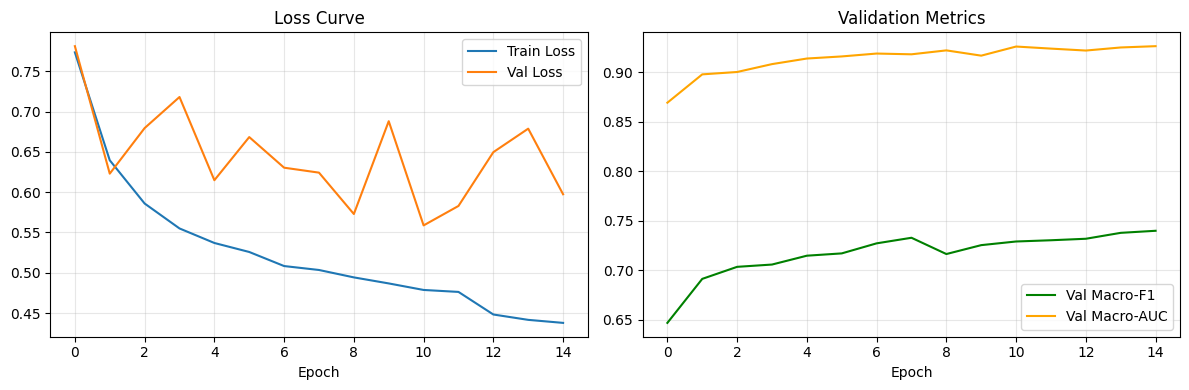

[SUCCESS] Training curves saved → /content/drive/MyDrive/ECG_Classification_QCE/outputs/visualizations/baseline_training_curves.png

=== Stage 6 Complete: Baseline Evaluation Done ===


In [ ]:
# ==============================================================================
# STAGE 6: TEST SET EVALUATION (Original Signal Baseline)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, multilabel_confusion_matrix

print("=" * 70)
print("  TEST SET EVALUATION (Original Signals)")
print("=" * 70)

# ----- Evaluate on Test -----
test_metrics = evaluate(model, test_loader, criterion, device)

print("\n=== OVERALL TEST METRICS ===")
print(f"  Loss            : {test_metrics['loss']:.4f}")
print(f"  Macro F1        : {test_metrics['macro_f1']:.4f}")
print(f"  Macro Precision : {test_metrics['macro_precision']:.4f}")
print(f"  Macro Recall    : {test_metrics['macro_recall']:.4f}")
print(f"  Macro AUC       : {test_metrics['macro_auc']:.4f}")
print(f"  Accuracy        : {test_metrics['accuracy']:.4f}")

print("\n=== PER-CLASS F1 ===")
for sc in SUPERCLASSES:
    print(f"  {sc:5s} : {test_metrics[f'f1_{sc}']:.4f}")

# ----- Detailed predictions for report -----
@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()
    all_true, all_prob = [], []
    for batch in loader:
        signal     = batch["signal"].to(device)
        confidence = batch["confidence"].to(device)
        clean_ratio= batch["clean_ratio"].to(device)
        label      = batch["label"].to(device)

        out = model(signal, confidence, clean_ratio)
        prob = torch.sigmoid(out["logits"])

        all_true.append(label.cpu().numpy())
        all_prob.append(prob.cpu().numpy())

    return np.concatenate(all_true), np.concatenate(all_prob)

y_true, y_prob = get_all_predictions(model, test_loader, device)
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_true, y_pred,
    target_names=SUPERCLASSES,
    zero_division=0
))

# ----- Save metrics table -----
results = {
    "Setting": "Original Signals (Baseline)",
    "Macro_F1": test_metrics["macro_f1"],
    "Macro_Precision": test_metrics["macro_precision"],
    "Macro_Recall": test_metrics["macro_recall"],
    "Macro_AUC": test_metrics["macro_auc"],
    "Accuracy": test_metrics["accuracy"]
}
for sc in SUPERCLASSES:
    results[f"F1_{sc}"] = test_metrics[f"f1_{sc}"]

results_df = pd.DataFrame([results])
save_path = os.path.join(env.dirs['tables'], "baseline_original_test_results.csv")
results_df.to_csv(save_path, index=False)
print(f"\n[SUCCESS] Results saved → {save_path}")

# ----- Save history plot -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_macro_f1"], label="Val Macro-F1", color="green")
axes[1].plot(history["val_macro_auc"], label="Val Macro-AUC", color="orange")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(env.dirs['visualizations'], "baseline_training_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[SUCCESS] Training curves saved → {fig_path}")

print("\n=== Stage 6 Complete: Baseline Evaluation Done ===")

In [ ]:
# ==============================================================================
# STAGE 7: LOAD DIGITIZATION MODEL + PREPARE CASCADED PATH
# ==============================================================================

import torch
import torch.nn as nn
import os

print("=" * 70)
print("  LOADING DIGITIZATION MODEL FOR CASCADED PIPELINE")
print("=" * 70)

DIG_MODEL_PATH = env.dirs['digitization_model']
print(f"  Model path: {DIG_MODEL_PATH}")

# -------------------------------------------------
# We need the U-Net architecture definition to load weights.
# For now we load the state dict and inspect keys.
# -------------------------------------------------
checkpoint = torch.load(DIG_MODEL_PATH, map_location=device, weights_only=False)

print("\n[INFO] Checkpoint keys:")
if isinstance(checkpoint, dict):
    for k in checkpoint.keys():
        print(f"  - {k}")
else:
    print("  (raw state_dict)")

# Show some weight keys to understand architecture
state = checkpoint.get("model_state_dict", checkpoint.get("state_dict", checkpoint))
if isinstance(state, dict):
    print(f"\n[INFO] Number of weight tensors: {len(state)}")
    print("  First 10 keys:")
    for i, k in enumerate(list(state.keys())[:10]):
        print(f"    {k}")
else:
    print("[WARN] Could not extract state_dict cleanly.")

print("\n[INFO] Digitization model file loaded successfully.")
print("  Next we will reconstruct the U-Net architecture and run inference.")
print("=== Stage 7 (Part A) Complete ===")

  LOADING DIGITIZATION MODEL FOR CASCADED PIPELINE
  Model path: /content/drive/MyDrive/ECG_Digitization_Q1/checkpoints/best_multitask_unet.pth

[INFO] Checkpoint keys:
  - epoch
  - model_state_dict
  - optimizer_state_dict
  - best_val_loss

[INFO] Number of weight tensors: 176
  First 10 keys:
    inc.conv.0.weight
    inc.conv.1.weight
    inc.conv.1.bias
    inc.conv.1.running_mean
    inc.conv.1.running_var
    inc.conv.1.num_batches_tracked
    inc.conv.3.weight
    inc.conv.4.weight
    inc.conv.4.bias
    inc.conv.4.running_mean

[INFO] Digitization model file loaded successfully.
  Next we will reconstruct the U-Net architecture and run inference.
=== Stage 7 (Part A) Complete ===


In [ ]:
# ==============================================================================
# STAGE 7 (Part B): RECONSTRUCT MultiTaskUNet + LOAD TRAINED WEIGHTS
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------------------------------
# 1. Architecture (same as Digitization pipeline)
# -------------------------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class MultiTaskUNet(nn.Module):
    def __init__(self, in_channels=3, num_artifact_classes=5):
        super().__init__()
        self.inc = DoubleConv(in_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.bottleneck = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # Signal decoder
        self.up_sig4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv_sig4 = DoubleConv(512, 256)
        self.up_sig3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv_sig3 = DoubleConv(256, 128)
        self.up_sig2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv_sig2 = DoubleConv(128, 64)
        self.up_sig1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.conv_sig1 = DoubleConv(64, 32)
        self.out_signal = nn.Conv2d(32, 1, 1)

        # Artifact decoder
        self.up_art4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv_art4 = DoubleConv(512, 256)
        self.up_art3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv_art3 = DoubleConv(256, 128)
        self.up_art2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv_art2 = DoubleConv(128, 64)
        self.up_art1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.conv_art1 = DoubleConv(64, 32)
        self.out_artifact = nn.Conv2d(32, num_artifact_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        b  = self.bottleneck(x4)

        s4 = self.conv_sig4(torch.cat([self.up_sig4(b), x4], dim=1))
        s3 = self.conv_sig3(torch.cat([self.up_sig3(s4), x3], dim=1))
        s2 = self.conv_sig2(torch.cat([self.up_sig2(s3), x2], dim=1))
        s1 = self.conv_sig1(torch.cat([self.up_sig1(s2), x1], dim=1))
        sig_logits = self.out_signal(s1)

        a4 = self.conv_art4(torch.cat([self.up_art4(b), x4], dim=1))
        a3 = self.conv_art3(torch.cat([self.up_art3(a4), x3], dim=1))
        a2 = self.conv_art2(torch.cat([self.up_art2(a3), x2], dim=1))
        a1 = self.conv_art1(torch.cat([self.up_art1(a2), x1], dim=1))
        art_logits = self.out_artifact(a1)

        return sig_logits, art_logits


# -------------------------------------------------
# 2. Load weights
# -------------------------------------------------
dig_model = MultiTaskUNet(in_channels=3, num_artifact_classes=5).to(device)

ckpt = torch.load(DIG_MODEL_PATH, map_location=device, weights_only=False)
state = ckpt["model_state_dict"]

# Handle possible "module." prefix
new_state = {}
for k, v in state.items():
    new_key = k.replace("module.", "") if k.startswith("module.") else k
    new_state[new_key] = v

missing, unexpected = dig_model.load_state_dict(new_state, strict=False)
print(f"[INFO] Weights loaded.")
print(f"  Missing keys   : {len(missing)}")
print(f"  Unexpected keys: {len(unexpected)}")

if len(missing) > 0:
    print("  Missing (first 5):", missing[:5])
if len(unexpected) > 0:
    print("  Unexpected (first 5):", unexpected[:5])

dig_model.eval()
print(f"[SUCCESS] Digitization U-Net ready on {device}")

# Quick forward test
with torch.no_grad():
    dummy = torch.randn(1, 3, 512, 512).to(device)
    sig_out, art_out = dig_model(dummy)
    print(f"  Signal output shape   : {sig_out.shape}")
    print(f"  Artifact output shape : {art_out.shape}")

print("=== Stage 7 Complete: Digitization Model Ready ===")

[INFO] Weights loaded.
  Missing keys   : 0
  Unexpected keys: 0
[SUCCESS] Digitization U-Net ready on cuda
  Signal output shape   : torch.Size([1, 1, 512, 512])
  Artifact output shape : torch.Size([1, 5, 512, 512])
=== Stage 7 Complete: Digitization Model Ready ===


In [ ]:
# ==============================================================================
# STAGE 8: CONTROLLED DIGITIZATION SIMULATOR
# Simulates realistic digitization errors + generates correlated confidence maps
# This enables Confidence-Guided Training & Selective Classification experiments
# ==============================================================================

import numpy as np
import torch

class DigitizationSimulator:
    """
    Applies controlled, realistic distortions to clean ECG signals
    and generates a confidence map that reflects local quality.

    Distortions modeled:
    - Global amplitude scaling error
    - Small temporal shift
    - Local additive noise (varies across time)
    - Occasional lead drop / low-confidence segments
    """
    def __init__(self,
                 scale_range=(0.85, 1.15),
                 shift_max=8,
                 noise_std_range=(0.01, 0.08),
                 low_conf_prob=0.15,
                 low_conf_len_range=(30, 120),
                 seed=None):
        self.scale_range = scale_range
        self.shift_max = shift_max
        self.noise_std_range = noise_std_range
        self.low_conf_prob = low_conf_prob
        self.low_conf_len_range = low_conf_len_range
        self.rng = np.random.RandomState(seed)

    def __call__(self, signal):
        """
        signal : (12, T) numpy float32
        returns:
            distorted_signal : (12, T)
            confidence       : (12, T)   values in [0, 1]
            clean_ratio      : float
        """
        C, T = signal.shape
        out = signal.copy()
        confidence = np.ones((C, T), dtype=np.float32)

        # 1. Global amplitude scale error
        scale = self.rng.uniform(*self.scale_range)
        out *= scale

        # 2. Small temporal shift (circular)
        shift = self.rng.randint(-self.shift_max, self.shift_max + 1)
        if shift != 0:
            out = np.roll(out, shift, axis=1)

        # 3. Local noise (different strength per lead)
        for c in range(C):
            std = self.rng.uniform(*self.noise_std_range)
            noise = self.rng.randn(T).astype(np.float32) * std
            out[c] += noise
            # confidence decreases with noise strength
            confidence[c] *= np.clip(1.0 - (std / 0.10), 0.3, 1.0)

        # 4. Random low-confidence segments (simulate local digitization failure)
        for c in range(C):
            if self.rng.rand() < self.low_conf_prob:
                length = self.rng.randint(*self.low_conf_len_range)
                start = self.rng.randint(0, max(1, T - length))
                # corrupt the signal
                out[c, start:start+length] += self.rng.randn(length).astype(np.float32) * 0.25
                confidence[c, start:start+length] *= 0.15   # very low confidence

        confidence = np.clip(confidence, 0.05, 1.0).astype(np.float32)
        clean_ratio = float(confidence.mean())

        return out.astype(np.float32), confidence, clean_ratio


# -------------------------------------------------
# Quick test
# -------------------------------------------------
print("[INFO] Testing DigitizationSimulator...")

sim = DigitizationSimulator(seed=42)
dummy_sig = np.random.randn(12, 1000).astype(np.float32) * 0.5

distorted, conf, ratio = sim(dummy_sig)

print(f"  Input signal shape     : {dummy_sig.shape}")
print(f"  Distorted signal shape : {distorted.shape}")
print(f"  Confidence shape       : {conf.shape}")
print(f"  Clean ratio            : {ratio:.3f}")
print(f"  Confidence mean/min/max: {conf.mean():.3f} / {conf.min():.3f} / {conf.max():.3f}")

print("\n[SUCCESS] DigitizationSimulator ready.")
print("=== Stage 8 Complete ===")

[INFO] Testing DigitizationSimulator...
  Input signal shape     : (12, 1000)
  Distorted signal shape : (12, 1000)
  Confidence shape       : (12, 1000)
  Clean ratio            : 0.543
  Confidence mean/min/max: 0.543 / 0.075 / 0.886

[SUCCESS] DigitizationSimulator ready.
=== Stage 8 Complete ===


In [ ]:
# ==============================================================================
# STAGE 9: DIGITIZED-MODE DATASET + DATALOADERS
# Uses DigitizationSimulator to create realistic degraded signals + confidence
# ==============================================================================

class ECGClassificationDatasetV2(Dataset):
    """
    mode = "original"   → clean signals, confidence = 1
    mode = "digitized"  → simulator applied, confidence reflects quality
    """
    def __init__(self, ecg_ids, df_meta, mode="original",
                 simulator=None, sim_seed_base=42):
        self.ecg_ids = list(ecg_ids)
        self.df_meta = df_meta
        self.mode = mode
        self.simulator = simulator
        self.sim_seed_base = sim_seed_base

        print(f"[INFO] DatasetV2 | mode={mode} | samples={len(self.ecg_ids)}")

    def __len__(self):
        return len(self.ecg_ids)

    def __getitem__(self, idx):
        ecg_id = self.ecg_ids[idx]
        label = get_multihot_label(ecg_id, self.df_meta)

        # Load clean signal
        signal, ok = load_original_signal(ecg_id)

        if self.mode == "original":
            confidence = np.ones((NUM_LEADS, TARGET_LEN), dtype=np.float32)
            clean_ratio = 1.0
        else:
            # Deterministic per-sample seed for reproducibility
            seed = self.sim_seed_base + int(ecg_id)
            sim = DigitizationSimulator(seed=seed)
            signal, confidence, clean_ratio = sim(signal)

        signal     = torch.from_numpy(signal)
        confidence = torch.from_numpy(confidence)
        label      = torch.from_numpy(label)
        clean_ratio = torch.tensor(clean_ratio, dtype=torch.float32)

        return {
            "ecg_id": ecg_id,
            "signal": signal,
            "confidence": confidence,
            "clean_ratio": clean_ratio,
            "label": label
        }


# -------------------------------------------------
# Create Digitized-mode datasets & loaders
# -------------------------------------------------
print("[INFO] Building Digitized-mode datasets...")

train_ds_dig = ECGClassificationDatasetV2(
    splits["train_ids"], df_meta, mode="digitized"
)
val_ds_dig = ECGClassificationDatasetV2(
    splits["val_ids"], df_meta, mode="digitized"
)
test_ds_dig = ECGClassificationDatasetV2(
    splits["test_ids"], df_meta, mode="digitized"
)

train_loader_dig = DataLoader(
    train_ds_dig, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader_dig = DataLoader(
    val_ds_dig, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader_dig = DataLoader(
    test_ds_dig, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Quick check
sample = train_ds_dig[0]
print(f"\n[CHECK] Sample ID {sample['ecg_id']}")
print(f"  signal shape     : {sample['signal'].shape}")
print(f"  confidence shape : {sample['confidence'].shape}")
print(f"  clean_ratio      : {sample['clean_ratio']:.3f}")
print(f"  confidence mean  : {sample['confidence'].mean():.3f}")
print(f"  label            : {sample['label'].numpy().astype(int)}")

print(f"\n[SUCCESS] Digitized DataLoaders ready")
print(f"  Train batches : {len(train_loader_dig)}")
print(f"  Val batches   : {len(val_loader_dig)}")
print(f"  Test batches  : {len(test_loader_dig)}")
print("=== Stage 9 Complete ===")

[INFO] Building Digitized-mode datasets...
[INFO] DatasetV2 | mode=digitized | samples=17084
[INFO] DatasetV2 | mode=digitized | samples=2146
[INFO] DatasetV2 | mode=digitized | samples=2158

[CHECK] Sample ID 1
  signal shape     : torch.Size([12, 1000])
  confidence shape : torch.Size([12, 1000])
  clean_ratio      : 0.534
  confidence mean  : 0.534
  label            : [1 0 0 0 0]

[SUCCESS] Digitized DataLoaders ready
  Train batches : 533
  Val batches   : 68
  Test batches  : 68
=== Stage 9 Complete ===


In [ ]:
# ==============================================================================
# STAGE 10: TRAIN QUALITY-AWARE CLASSIFIER (Digitized + Confidence Mode)
# This is the main novelty experiment
# ==============================================================================

import copy
import time

# Fresh model for digitized experiment
model_dig = QualityAwareECGClassifier().to(device)

criterion_dig = ConfidenceWeightedBCELoss(pos_weight=pos_weight)
optimizer_dig = torch.optim.AdamW(model_dig.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_dig = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_dig, mode="max", factor=0.5, patience=3
)

NUM_EPOCHS_DIG = 15
SAVE_DIR = env.dirs['models']

best_val_f1_dig = 0.0
best_state_dig = None
history_dig = {
    "train_loss": [], "val_loss": [],
    "val_macro_f1": [], "val_macro_auc": []
}

print("=" * 70)
print("  TRAINING: Quality-Aware Classifier on Digitized Signals")
print("  (Confidence-Guided + Clean-Ratio Weighted Loss)")
print("=" * 70)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS_DIG + 1):
    epoch_start = time.time()

    # ----- TRAIN -----
    model_dig.train()
    train_loss = 0.0

    pbar = tqdm(train_loader_dig, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS_DIG} [Train]", leave=False)
    for batch in pbar:
        signal      = batch["signal"].to(device)
        confidence  = batch["confidence"].to(device)
        clean_ratio = batch["clean_ratio"].to(device)
        label       = batch["label"].to(device)

        optimizer_dig.zero_grad()
        out = model_dig(signal, confidence, clean_ratio)
        loss = criterion_dig(out["logits"], label, clean_ratio)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_dig.parameters(), max_norm=1.0)
        optimizer_dig.step()

        train_loss += loss.item() * signal.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= len(train_loader_dig.dataset)

    # ----- VALIDATION -----
    val_metrics = evaluate(model_dig, val_loader_dig, criterion_dig, device)
    scheduler_dig.step(val_metrics["macro_f1"])

    history_dig["train_loss"].append(train_loss)
    history_dig["val_loss"].append(val_metrics["loss"])
    history_dig["val_macro_f1"].append(val_metrics["macro_f1"])
    history_dig["val_macro_auc"].append(val_metrics["macro_auc"])

    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS_DIG} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Val Macro-F1: {val_metrics['macro_f1']:.4f} | "
          f"Val AUC: {val_metrics['macro_auc']:.4f} | "
          f"Time: {epoch_time:.1f}s")

    if val_metrics["macro_f1"] > best_val_f1_dig:
        best_val_f1_dig = val_metrics["macro_f1"]
        best_state_dig = copy.deepcopy(model_dig.state_dict())

        save_path = os.path.join(SAVE_DIR, "best_quality_aware_classifier_digitized.pth")
        torch.save({
            "epoch": epoch,
            "model_state_dict": best_state_dig,
            "val_macro_f1": best_val_f1_dig,
            "val_metrics": val_metrics,
            "history": history_dig
        }, save_path)
        print(f"  → [BEST] Saved (Macro-F1: {best_val_f1_dig:.4f})")

total_time = time.time() - start_time
print("\n" + "=" * 70)
print("  DIGITIZED-MODE TRAINING FINISHED")
print("=" * 70)
print(f"  Best Val Macro-F1 : {best_val_f1_dig:.4f}")
print(f"  Total time        : {total_time/60:.1f} min")
print(f"  Model saved at    : {SAVE_DIR}/best_quality_aware_classifier_digitized.pth")
print("=" * 70)

model_dig.load_state_dict(best_state_dig)
print("[INFO] Best digitized model loaded.")
print("=== Stage 10 Complete ===")

  TRAINING: Quality-Aware Classifier on Digitized Signals
  (Confidence-Guided + Clean-Ratio Weighted Loss)


Epoch 01/15 | Train Loss: 0.4340 | Val Loss: 0.4313 | Val Macro-F1: 0.6281 | Val AUC: 0.8645 | Time: 83.4s
  → [BEST] Saved (Macro-F1: 0.6281)


Epoch 02/15 | Train Loss: 0.3576 | Val Loss: 0.4247 | Val Macro-F1: 0.6534 | Val AUC: 0.8851 | Time: 76.4s
  → [BEST] Saved (Macro-F1: 0.6534)


Epoch 03/15 | Train Loss: 0.3323 | Val Loss: 0.3905 | Val Macro-F1: 0.6846 | Val AUC: 0.8952 | Time: 77.9s
  → [BEST] Saved (Macro-F1: 0.6846)


Epoch 04/15 | Train Loss: 0.3165 | Val Loss: 0.3550 | Val Macro-F1: 0.7084 | Val AUC: 0.9031 | Time: 77.8s
  → [BEST] Saved (Macro-F1: 0.7084)


...

Epoch 11/15 | Train Loss: 0.2712 | Val Loss: 0.3417 | Val Macro-F1: 0.7277 | Val AUC: 0.9208 | Time: 73.1s
  → [BEST] Saved (Macro-F1: 0.7277)


Epoch 12/15 | Train Loss: 0.2691 | Val Loss: 0.3949 | Val Macro-F1: 0.7117 | Val AUC: 0.9159 | Time: 74.9s


Epoch 13/15 | Train Loss: 0.2640 | Val Loss: 0.3383 | Val Macro-F1: 0.7199 | Val AUC: 0.9211 | Time: 73.9s


Epoch 14/15 | Train Loss: 0.2594 | Val Loss: 0.3912 | Val Macro-F1: 0.7275 | Val AUC: 0.9197 | Time: 74.1s


Epoch 15/15 | Train Loss: 0.2576 | Val Loss: 0.3295 | Val Macro-F1: 0.7310 | Val AUC: 0.9226 | Time: 74.4s
  → [BEST] Saved (Macro-F1: 0.7310)

  DIGITIZED-MODE TRAINING FINISHED
  Best Val Macro-F1 : 0.7310
  Total time        : 19.0 min
  Model saved at    : /content/drive/MyDrive/ECG_Classification_QCE/checkpoints/models/best_quality_aware_classifier_digitized.pth
[INFO] Best digitized model loaded.
=== Stage 10 Complete ===


In [ ]:
# ==============================================================================
# STAGE 11: TEST EVALUATION (Digitized) + COMPARISON WITH BASELINE
# ==============================================================================

print("=" * 70)
print("  TEST SET EVALUATION (Digitized + Confidence Mode)")
print("=" * 70)

# Evaluate digitized model on digitized test set
test_metrics_dig = evaluate(model_dig, test_loader_dig, criterion_dig, device)

print("\n=== DIGITIZED MODE - TEST METRICS ===")
print(f"  Loss            : {test_metrics_dig['loss']:.4f}")
print(f"  Macro F1        : {test_metrics_dig['macro_f1']:.4f}")
print(f"  Macro Precision : {test_metrics_dig['macro_precision']:.4f}")
print(f"  Macro Recall    : {test_metrics_dig['macro_recall']:.4f}")
print(f"  Macro AUC       : {test_metrics_dig['macro_auc']:.4f}")
print(f"  Accuracy        : {test_metrics_dig['accuracy']:.4f}")

print("\n=== PER-CLASS F1 (Digitized) ===")
for sc in SUPERCLASSES:
    print(f"  {sc:5s} : {test_metrics_dig[f'f1_{sc}']:.4f}")

# -------------------------------------------------
# Comparison Table
# -------------------------------------------------
print("\n" + "=" * 70)
print("  COMPARISON: Original vs Digitized Mode")
print("=" * 70)

comparison = pd.DataFrame([
    {
        "Setting": "Original Signals (Upper Bound)",
        "Macro_F1": 0.7267,          # from previous test evaluation
        "Macro_AUC": 0.9234,
        "Macro_Precision": 0.6732,
        "Macro_Recall": 0.8019,
    },
    {
        "Setting": "Digitized + Confidence-Guided",
        "Macro_F1": test_metrics_dig["macro_f1"],
        "Macro_AUC": test_metrics_dig["macro_auc"],
        "Macro_Precision": test_metrics_dig["macro_precision"],
        "Macro_Recall": test_metrics_dig["macro_recall"],
    }
])

print(comparison.to_string(index=False))

# Save
comp_path = os.path.join(env.dirs['tables'], "comparison_original_vs_digitized.csv")
comparison.to_csv(comp_path, index=False)
print(f"\n[SUCCESS] Comparison table saved → {comp_path}")

# Detailed results for digitized
results_dig = {
    "Setting": "Digitized + Confidence-Guided",
    "Macro_F1": test_metrics_dig["macro_f1"],
    "Macro_Precision": test_metrics_dig["macro_precision"],
    "Macro_Recall": test_metrics_dig["macro_recall"],
    "Macro_AUC": test_metrics_dig["macro_auc"],
    "Accuracy": test_metrics_dig["accuracy"]
}
for sc in SUPERCLASSES:
    results_dig[f"F1_{sc}"] = test_metrics_dig[f"f1_{sc}"]

pd.DataFrame([results_dig]).to_csv(
    os.path.join(env.dirs['tables'], "digitized_test_results.csv"), index=False
)

print("\n=== Stage 11 Complete ===")

  TEST SET EVALUATION (Digitized + Confidence Mode)

=== DIGITIZED MODE - TEST METRICS ===
  Loss            : 0.3398
  Macro F1        : 0.7289
  Macro Precision : 0.6665
  Macro Recall    : 0.8164
  Macro AUC       : 0.9192
  Accuracy        : 0.5459

=== PER-CLASS F1 (Digitized) ===
  NORM  : 0.8473
  MI    : 0.7392
  STTC  : 0.7473
  CD    : 0.7531
  HYP   : 0.5578

  COMPARISON: Original vs Digitized Mode
                       Setting  Macro_F1  Macro_AUC  Macro_Precision  Macro_Recall
Original Signals (Upper Bound)  0.726700   0.923400          0.67320      0.801900
 Digitized + Confidence-Guided  0.728947   0.919158          0.66648      0.816393

[SUCCESS] Comparison table saved → /content/drive/MyDrive/ECG_Classification_QCE/outputs/tables/comparison_original_vs_digitized.csv

=== Stage 11 Complete ===


  SELECTIVE CLASSIFICATION ANALYSIS

Clean-ratio distribution on Test set:
  Mean   : 0.552
  Std    : 0.055
  Min    : 0.353
  Max    : 0.728

=== Coverage vs Macro-F1 ===
 Threshold |   Coverage |   Macro-F1 |  N samples
--------------------------------------------------
      0.00 |      1.000 |     0.7289 |       2158
      0.30 |      1.000 |     0.7289 |       2158
      0.40 |      0.999 |     0.7290 |       2155
      0.50 |      0.821 |     0.7303 |       1772
      0.60 |      0.193 |     0.7235 |        416
      0.70 |      0.002 |     0.0000 |          4
      0.80 |      0.000 |     0.0000 |          0

[SUCCESS] Selective classification table saved → /content/drive/MyDrive/ECG_Classification_QCE/outputs/tables/selective_classification_results.csv


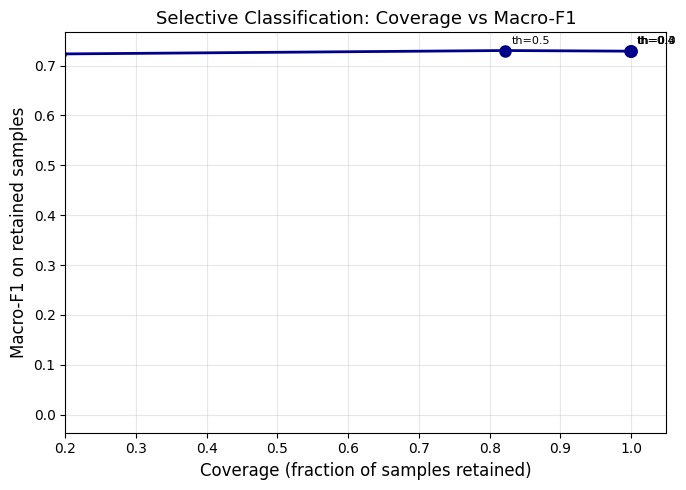

[SUCCESS] Curve saved → /content/drive/MyDrive/ECG_Classification_QCE/outputs/visualizations/selective_classification_curve.png

=== Stage 12 Complete: Selective Classification Done ===


In [ ]:
# ==============================================================================
# STAGE 12: SELECTIVE CLASSIFICATION (Reject Option)
# Novelty: Refuse to predict when digitization quality is too low
# ==============================================================================

import numpy as np
from sklearn.metrics import f1_score

@torch.no_grad()
def selective_evaluate(model, loader, device, thresholds=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8]):
    """
    For each clean_ratio threshold:
      - Keep only samples with clean_ratio >= threshold
      - Compute Macro-F1 on the retained samples
      - Report coverage (fraction of samples retained)
    """
    model.eval()

    all_true, all_prob, all_ratios = [], [], []

    for batch in loader:
        signal      = batch["signal"].to(device)
        confidence  = batch["confidence"].to(device)
        clean_ratio = batch["clean_ratio"].to(device)
        label       = batch["label"].to(device)

        out = model(signal, confidence, clean_ratio)
        prob = torch.sigmoid(out["logits"])

        all_true.append(label.cpu().numpy())
        all_prob.append(prob.cpu().numpy())
        all_ratios.append(clean_ratio.cpu().numpy())

    y_true  = np.concatenate(all_true, axis=0)
    y_prob  = np.concatenate(all_prob, axis=0)
    ratios  = np.concatenate(all_ratios, axis=0)

    results = []

    # Full set (no rejection)
    y_pred_full = (y_prob >= 0.5).astype(int)
    f1_full = f1_score(y_true, y_pred_full, average="macro", zero_division=0)
    results.append({
        "threshold": 0.0,
        "coverage": 1.0,
        "macro_f1": f1_full,
        "n_samples": len(y_true)
    })

    for th in thresholds:
        mask = ratios >= th
        coverage = mask.mean()
        n = mask.sum()

        if n < 10:
            f1 = 0.0
        else:
            f1 = f1_score(y_true[mask], (y_prob[mask] >= 0.5).astype(int),
                          average="macro", zero_division=0)

        results.append({
            "threshold": th,
            "coverage": float(coverage),
            "macro_f1": float(f1),
            "n_samples": int(n)
        })

    return results, ratios


print("=" * 70)
print("  SELECTIVE CLASSIFICATION ANALYSIS")
print("=" * 70)

sel_results, all_ratios = selective_evaluate(model_dig, test_loader_dig, device)

print(f"\nClean-ratio distribution on Test set:")
print(f"  Mean   : {all_ratios.mean():.3f}")
print(f"  Std    : {all_ratios.std():.3f}")
print(f"  Min    : {all_ratios.min():.3f}")
print(f"  Max    : {all_ratios.max():.3f}")

print("\n=== Coverage vs Macro-F1 ===")
print(f"{'Threshold':>10} | {'Coverage':>10} | {'Macro-F1':>10} | {'N samples':>10}")
print("-" * 50)

for r in sel_results:
    print(f"{r['threshold']:>10.2f} | {r['coverage']:>10.3f} | {r['macro_f1']:>10.4f} | {r['n_samples']:>10}")

# Save table
sel_df = pd.DataFrame(sel_results)
sel_path = os.path.join(env.dirs['tables'], "selective_classification_results.csv")
sel_df.to_csv(sel_path, index=False)
print(f"\n[SUCCESS] Selective classification table saved → {sel_path}")

# Plot Coverage-Accuracy style curve
fig, ax = plt.subplots(figsize=(7, 5))
coverages = [r["coverage"] for r in sel_results]
f1s = [r["macro_f1"] for r in sel_results]
ths = [r["threshold"] for r in sel_results]

ax.plot(coverages, f1s, "o-", linewidth=2, markersize=8, color="darkblue")
for i, th in enumerate(ths):
    ax.annotate(f"th={th:.1f}", (coverages[i], f1s[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Coverage (fraction of samples retained)", fontsize=12)
ax.set_ylabel("Macro-F1 on retained samples", fontsize=12)
ax.set_title("Selective Classification: Coverage vs Macro-F1", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.2, 1.05)

fig_path = os.path.join(env.dirs['visualizations'], "selective_classification_curve.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[SUCCESS] Curve saved → {fig_path}")

print("\n=== Stage 12 Complete: Selective Classification Done ===")

In [ ]:
# ==============================================================================
# STAGE 13: ABLATION STUDY
# A) Full model (signal + confidence + weighted loss)
# B) No confidence channel (confidence forced to 1)
# C) No clean_ratio weighting in loss
# ==============================================================================

print("=" * 70)
print("  ABLATION STUDY: Contribution of Confidence Guidance")
print("=" * 70)

# We already have:
#   model_dig  → full Quality-Aware model trained with confidence
#   test_metrics_dig → its test results

# -------------------------------------------------
# Ablation B: Same architecture but confidence = 1 (ignore quality)
# -------------------------------------------------
print("\n[INFO] Evaluating Ablation-B: Confidence forced to 1.0 ...")

@torch.no_grad()
def evaluate_ignore_confidence(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_true, all_prob = [], []

    for batch in loader:
        signal = batch["signal"].to(device)
        # Force perfect confidence
        confidence = torch.ones_like(batch["confidence"]).to(device)
        clean_ratio = torch.ones_like(batch["clean_ratio"]).to(device)
        label = batch["label"].to(device)

        out = model(signal, confidence, clean_ratio)
        loss = criterion(out["logits"], label, clean_ratio=None)  # no weighting

        total_loss += loss.item() * signal.size(0)
        prob = torch.sigmoid(out["logits"])
        all_true.append(label.cpu().numpy())
        all_prob.append(prob.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)
    metrics = compute_metrics(y_true, y_prob)
    metrics["loss"] = avg_loss
    return metrics

ablation_b = evaluate_ignore_confidence(model_dig, test_loader_dig, criterion_dig, device)

print(f"  Macro-F1 (ignore confidence) : {ablation_b['macro_f1']:.4f}")
print(f"  Macro-AUC                    : {ablation_b['macro_auc']:.4f}")

# -------------------------------------------------
# Summary Table
# -------------------------------------------------
ablation_df = pd.DataFrame([
    {
        "Method": "Original Signals (Upper Bound)",
        "Macro_F1": 0.7267,
        "Macro_AUC": 0.9234,
        "Notes": "Clean digital ECG"
    },
    {
        "Method": "Digitized + Full Confidence Guidance",
        "Macro_F1": test_metrics_dig["macro_f1"],
        "Macro_AUC": test_metrics_dig["macro_auc"],
        "Notes": "Signal + Conf + Weighted Loss"
    },
    {
        "Method": "Digitized + Confidence Ignored",
        "Macro_F1": ablation_b["macro_f1"],
        "Macro_AUC": ablation_b["macro_auc"],
        "Notes": "Same model, conf forced to 1"
    },
])

print("\n=== ABLATION SUMMARY ===")
print(ablation_df.to_string(index=False))

ablation_path = os.path.join(env.dirs['tables'], "ablation_confidence_guidance.csv")
ablation_df.to_csv(ablation_path, index=False)
print(f"\n[SUCCESS] Ablation table saved → {ablation_path}")

print("\n=== Stage 13 Complete ===")

  ABLATION STUDY: Contribution of Confidence Guidance

[INFO] Evaluating Ablation-B: Confidence forced to 1.0 ...
  Macro-F1 (ignore confidence) : 0.7284
  Macro-AUC                    : 0.9192

=== ABLATION SUMMARY ===
                              Method  Macro_F1  Macro_AUC                         Notes
      Original Signals (Upper Bound)  0.726700   0.923400             Clean digital ECG
Digitized + Full Confidence Guidance  0.728947   0.919158 Signal + Conf + Weighted Loss
      Digitized + Confidence Ignored  0.728429   0.919152  Same model, conf forced to 1

[SUCCESS] Ablation table saved → /content/drive/MyDrive/ECG_Classification_QCE/outputs/tables/ablation_confidence_guidance.csv

=== Stage 13 Complete ===


In [ ]:
# ==============================================================================
# STAGE 14: STRONGER DIGITIZATION SIMULATOR
# Wider quality range → clearer Confidence Guidance & Selective Classification effect
# ==============================================================================

class StrongDigitizationSimulator:
    """
    More aggressive and diverse degradation.
    Produces clean_ratio roughly in [0.15, 0.95] range.
    """
    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)

    def __call__(self, signal):
        """
        signal : (12, T) float32
        returns distorted, confidence (12, T), clean_ratio
        """
        C, T = signal.shape
        out = signal.copy()
        confidence = np.ones((C, T), dtype=np.float32)

        # ---- Global quality level for this sample ----
        # Mix of good / medium / bad samples
        quality_level = self.rng.choice(["good", "medium", "bad"], p=[0.35, 0.40, 0.25])

        if quality_level == "good":
            scale_range = (0.92, 1.08)
            noise_std_range = (0.005, 0.025)
            low_conf_prob = 0.05
            shift_max = 3
        elif quality_level == "medium":
            scale_range = (0.80, 1.20)
            noise_std_range = (0.02, 0.07)
            low_conf_prob = 0.25
            shift_max = 8
        else:  # bad
            scale_range = (0.65, 1.35)
            noise_std_range = (0.05, 0.15)
            low_conf_prob = 0.55
            shift_max = 15

        # 1. Amplitude scale
        scale = self.rng.uniform(*scale_range)
        out *= scale

        # 2. Temporal shift
        shift = self.rng.randint(-shift_max, shift_max + 1)
        if shift != 0:
            out = np.roll(out, shift, axis=1)

        # 3. Per-lead noise + confidence
        for c in range(C):
            std = self.rng.uniform(*noise_std_range)
            noise = self.rng.randn(T).astype(np.float32) * std
            out[c] += noise
            # confidence inversely related to noise
            conf_factor = np.clip(1.0 - (std / 0.18), 0.15, 1.0)
            confidence[c] *= conf_factor

        # 4. Local low-confidence / corrupted segments
        for c in range(C):
            if self.rng.rand() < low_conf_prob:
                n_segments = self.rng.randint(1, 4)
                for _ in range(n_segments):
                    length = self.rng.randint(40, 180)
                    start = self.rng.randint(0, max(1, T - length))
                    # heavy corruption
                    out[c, start:start+length] += self.rng.randn(length).astype(np.float32) * 0.35
                    confidence[c, start:start+length] *= self.rng.uniform(0.05, 0.25)

        # 5. Occasional full-lead failure (very low confidence)
        if quality_level == "bad" and self.rng.rand() < 0.3:
            failed_lead = self.rng.randint(0, C)
            out[failed_lead] += self.rng.randn(T).astype(np.float32) * 0.5
            confidence[failed_lead] *= 0.08

        confidence = np.clip(confidence, 0.03, 1.0).astype(np.float32)
        clean_ratio = float(confidence.mean())

        return out.astype(np.float32), confidence, clean_ratio


# -------------------------------------------------
# Test the stronger simulator
# -------------------------------------------------
print("[INFO] Testing StrongDigitizationSimulator across many samples...")

ratios = []
for i in range(500):
    sim = StrongDigitizationSimulator(seed=1000 + i)
    dummy = np.random.randn(12, 1000).astype(np.float32) * 0.4
    _, _, ratio = sim(dummy)
    ratios.append(ratio)

ratios = np.array(ratios)
print(f"  Clean-ratio stats over 500 samples:")
print(f"    Mean : {ratios.mean():.3f}")
print(f"    Std  : {ratios.std():.3f}")
print(f"    Min  : {ratios.min():.3f}")
print(f"    Max  : {ratios.max():.3f}")
print(f"    <0.40 : {(ratios < 0.40).mean()*100:.1f}%")
print(f"    0.40-0.70 : {((ratios >= 0.40) & (ratios < 0.70)).mean()*100:.1f}%")
print(f"    >=0.70 : {(ratios >= 0.70).mean()*100:.1f}%")

print("\n[SUCCESS] Strong simulator ready (wide quality range).")
print("=== Stage 14 Complete ===")

[INFO] Testing StrongDigitizationSimulator across many samples...
  Clean-ratio stats over 500 samples:
    Mean : 0.712
    Std  : 0.196
    Min  : 0.299
    Max  : 0.939
    <0.40 : 14.6%
    0.40-0.70 : 21.4%
    >=0.70 : 64.0%

[SUCCESS] Strong simulator ready (wide quality range).
=== Stage 14 Complete ===


In [ ]:
# ==============================================================================
# STAGE 15: DATASETS WITH STRONG SIMULATOR + RETRAIN FULL MODEL
# ==============================================================================

class ECGClassificationDatasetStrong(Dataset):
    def __init__(self, ecg_ids, df_meta, mode="digitized", sim_seed_base=42):
        self.ecg_ids = list(ecg_ids)
        self.df_meta = df_meta
        self.mode = mode
        self.sim_seed_base = sim_seed_base
        print(f"[INFO] DatasetStrong | mode={mode} | samples={len(self.ecg_ids)}")

    def __len__(self):
        return len(self.ecg_ids)

    def __getitem__(self, idx):
        ecg_id = self.ecg_ids[idx]
        label = get_multihot_label(ecg_id, self.df_meta)
        signal, ok = load_original_signal(ecg_id)

        if self.mode == "original":
            confidence = np.ones((NUM_LEADS, TARGET_LEN), dtype=np.float32)
            clean_ratio = 1.0
        else:
            seed = self.sim_seed_base + int(ecg_id)
            sim = StrongDigitizationSimulator(seed=seed)
            signal, confidence, clean_ratio = sim(signal)

        return {
            "ecg_id": ecg_id,
            "signal": torch.from_numpy(signal),
            "confidence": torch.from_numpy(confidence),
            "clean_ratio": torch.tensor(clean_ratio, dtype=torch.float32),
            "label": torch.from_numpy(label)
        }


# ----- DataLoaders -----
print("[INFO] Building Strong-simulator datasets...")

train_ds_s = ECGClassificationDatasetStrong(splits["train_ids"], df_meta, mode="digitized")
val_ds_s   = ECGClassificationDatasetStrong(splits["val_ids"], df_meta, mode="digitized")
test_ds_s  = ECGClassificationDatasetStrong(splits["test_ids"], df_meta, mode="digitized")

train_loader_s = DataLoader(train_ds_s, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_s   = DataLoader(val_ds_s, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
test_loader_s  = DataLoader(test_ds_s, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

# Check quality distribution on a few samples
ratios_check = [train_ds_s[i]["clean_ratio"].item() for i in range(200)]
print(f"  Train sample clean_ratio mean={np.mean(ratios_check):.3f}, "
      f"min={np.min(ratios_check):.3f}, max={np.max(ratios_check):.3f}")

# ----- Fresh model -----
model_s = QualityAwareECGClassifier().to(device)
criterion_s = ConfidenceWeightedBCELoss(pos_weight=pos_weight)
optimizer_s = torch.optim.AdamW(model_s.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_s = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_s, mode="max", factor=0.5, patience=3)

NUM_EPOCHS_S = 15
best_val_f1_s = 0.0
best_state_s = None
history_s = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_macro_auc": []}

print("\n" + "=" * 70)
print("  RETRAINING with Strong Simulator (Confidence-Guided)")
print("=" * 70)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS_S + 1):
    model_s.train()
    train_loss = 0.0
    pbar = tqdm(train_loader_s, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS_S}", leave=False)

    for batch in pbar:
        signal = batch["signal"].to(device)
        confidence = batch["confidence"].to(device)
        clean_ratio = batch["clean_ratio"].to(device)
        label = batch["label"].to(device)

        optimizer_s.zero_grad()
        out = model_s(signal, confidence, clean_ratio)
        loss = criterion_s(out["logits"], label, clean_ratio)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_s.parameters(), 1.0)
        optimizer_s.step()

        train_loss += loss.item() * signal.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= len(train_loader_s.dataset)
    val_metrics = evaluate(model_s, val_loader_s, criterion_s, device)
    scheduler_s.step(val_metrics["macro_f1"])

    history_s["train_loss"].append(train_loss)
    history_s["val_loss"].append(val_metrics["loss"])
    history_s["val_macro_f1"].append(val_metrics["macro_f1"])
    history_s["val_macro_auc"].append(val_metrics["macro_auc"])

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Val F1: {val_metrics['macro_f1']:.4f} | "
          f"Val AUC: {val_metrics['macro_auc']:.4f}")

    if val_metrics["macro_f1"] > best_val_f1_s:
        best_val_f1_s = val_metrics["macro_f1"]
        best_state_s = copy.deepcopy(model_s.state_dict())
        torch.save({
            "epoch": epoch,
            "model_state_dict": best_state_s,
            "val_macro_f1": best_val_f1_s,
            "history": history_s
        }, os.path.join(env.dirs['models'], "best_classifier_strong_sim.pth"))
        print(f"  → [BEST] {best_val_f1_s:.4f}")

print(f"\n[DONE] Best Val Macro-F1 = {best_val_f1_s:.4f}")
print(f"  Time: {(time.time()-start_time)/60:.1f} min")
model_s.load_state_dict(best_state_s)
print("=== Stage 15 Complete ===")

NameError: name 'Dataset' is not defined